## Util

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Core model

In [17]:
import torch
import torch.nn as nn

class ScamGuardLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super(ScamGuardLSTM, self).__init__()
        
        # 1. Embedding Layer: Converts token integers into dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. LSTM Layer: The sequential "memory" of the model
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        
        # 3. Fully Connected Layer: Maps the LSTM output to our classes (0 = Safe, 1 = Scam)
        # Multiply hidden_dim by 2 because it's bidirectional
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        
        # 4. Dropout: Regularization to prevent overfitting on small datasets
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text, text_lengths):
        # text shape: [batch_size, sequence_length]
        embedded = self.dropout(self.embedding(text))

        # Ensure lengths are at least 1 and on CPU for packing
        text_lengths = text_lengths.clamp(min=1).cpu()
        
        # Pack sequence to handle variable message lengths efficiently in memory
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths, batch_first=True, enforce_sorted=False
        )
        
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        # Extract the final hidden state from both the forward and backward passes
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
            
        # Pass through the linear layer for the final logit prediction
        return self.fc(hidden)


## Data preprocessing

In [18]:
import sys

from data_loader import load_scam_data, load_embeddings

dataset = load_scam_data()
glove = load_embeddings()

glove_weights = glove.vectors

Downloading/Loading SMS Spam dataset...

Sample Data Structure:
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}

Downloading/Loading GloVe Embeddings...
(Note: This is an ~800MB download the first time you run it. Grab a coffee.)

The shape of the word vector for 'scam' is: torch.Size([100])


### Tokenize and build vocabulary

In [19]:
import torch
from collections import Counter

# 1. Flatten all messages to count word frequency
all_text = " ".join(dataset['train']['sms']).lower().split()
word_counts = Counter(all_text)

# 2. Create a vocabulary (only keep words that appear at least twice)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count > 1:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 5545


### Create embedding matrix

In [20]:
embedding_dim = 100
# Initialize matrix with zeros or random numbers
target_vocab_size = len(vocab)
embedding_matrix = torch.zeros((target_vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in glove.stoi: # Check if word exists in GloVe
        embedding_matrix[idx] = glove.vectors[glove.stoi[word]]
    else:
        # For <UNK> or missing words, use a random normal vector
        embedding_matrix[idx] = torch.randn(embedding_dim)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: torch.Size([5545, 100])


### Numericalize and pad sequences

In [21]:
def encode_and_pad(text, max_len=50):
    tokens = text.lower().split()
    # Convert words to indices
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    # Pad or Truncate
    if len(indices) < max_len:
        indices += [vocab["<PAD>"]] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

# Apply to the dataset
train_data = [encode_and_pad(msg) for msg in dataset['train']['sms']]
train_labels = dataset['train']['label'] # 0 for ham, 1 for spam

# Convert to Tensors
X_train = torch.tensor(train_data)
y_train = torch.tensor(train_labels)

In [22]:
from torch.utils.data import TensorDataset, DataLoader

# 1. Split the original Hugging Face dataset (if you haven't already)
# This creates a 80/20 split
split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)

# 2. Process Training Data (Re-doing this to ensure consistency)
train_msgs = [encode_and_pad(msg) for msg in split_dataset['train']['sms']]
train_labels = split_dataset['train']['label']
X_train = torch.tensor(train_msgs)
y_train = torch.tensor(train_labels)

# 3. Process Test Data (The missing piece!)
test_msgs = [encode_and_pad(msg) for msg in split_dataset['test']['sms']]
test_labels = split_dataset['test']['label']
X_test = torch.tensor(test_msgs)
y_test = torch.tensor(test_labels)

# 4. Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle test data

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 4459, Test samples: 1115


### Wrap in dataloader

In [28]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Test a batch
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape}") # Should be [32, 50]

Batch X shape: torch.Size([32, 50])


## Training

In [29]:
import torch.optim as optim
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ScamGuardLSTM(
    vocab_size=len(glove.stoi), 
    embedding_dim=100, 
    hidden_dim=256, 
    output_dim=1, 
    n_layers=2, 
    bidirectional=True, 
    dropout=0.5
)
model.embedding.weight.data.copy_(glove_weights) # Load pre-trained GloVe
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss() # Best for binary classification (Scam vs. Safe)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        
        # Calculate lengths: count how many non-zero tokens are in each row
        # (Assuming 0 is your <PAD> token index)
        lengths = (texts != 0).sum(dim=1).cpu() 
        
        optimizer.zero_grad()
        
        # Pass both arguments to the model
        predictions = model(texts, lengths).squeeze(1) 
        
        loss = criterion(predictions, labels.float())
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        preds = torch.round(torch.sigmoid(predictions))
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return epoch_loss / len(loader), correct / total

In [30]:
N_EPOCHS = 10
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    # valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    
    # Save the best model for the final report
    if train_loss < best_valid_loss:
        best_valid_loss = train_loss
        torch.save(model.state_dict(), 'scam-guard-lstm.pt')

Epoch: 01
	Train Loss: 0.285 | Train Acc: 89.26%
Epoch: 02
	Train Loss: 0.145 | Train Acc: 95.04%
Epoch: 03
	Train Loss: 0.092 | Train Acc: 96.86%
Epoch: 04
	Train Loss: 0.068 | Train Acc: 97.94%
Epoch: 05
	Train Loss: 0.060 | Train Acc: 98.05%
Epoch: 06
	Train Loss: 0.047 | Train Acc: 98.47%
Epoch: 07
	Train Loss: 0.037 | Train Acc: 98.70%
Epoch: 08
	Train Loss: 0.036 | Train Acc: 98.86%
Epoch: 09
	Train Loss: 0.029 | Train Acc: 99.01%
Epoch: 10
	Train Loss: 0.016 | Train Acc: 99.48%


In [31]:
def evaluate(model, loader, criterion, device):
    model.eval() # Set model to evaluation mode
    epoch_loss = 0
    correct = 0
    total = 0
    
    # Disable gradient calculation for efficiency and to ensure no learning happens
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            
            # Re-calculate lengths for the packed sequence
            lengths = (texts != 0).sum(dim=1).cpu()
            
            # Forward pass
            predictions = model(texts, lengths).squeeze(1)
            
            # Calculate loss
            loss = criterion(predictions, labels.float())
            
            epoch_loss += loss.item()
            
            # Convert logits to probabilities (0 to 1) and then to binary (0 or 1)
            preds = torch.round(torch.sigmoid(predictions))
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return epoch_loss / len(loader), correct / total

In [32]:
valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train

In [33]:
print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc: {valid_acc*100:.2f}%')

	Valid Loss: 0.073 | Valid Acc: 98.39%


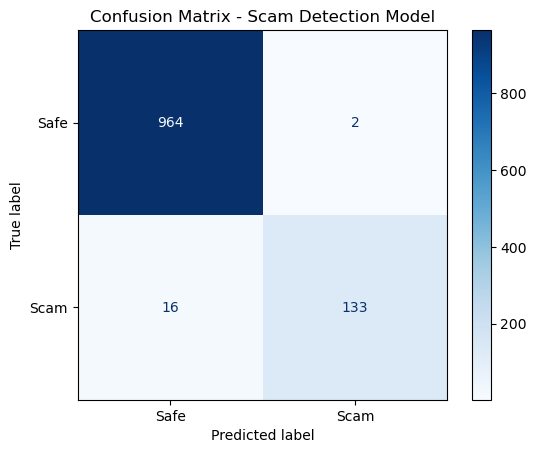

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        predictions = model(texts, lengths).squeeze(1)
        preds = torch.round(torch.sigmoid(predictions))

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Scam"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Scam Detection Model")
plt.show()

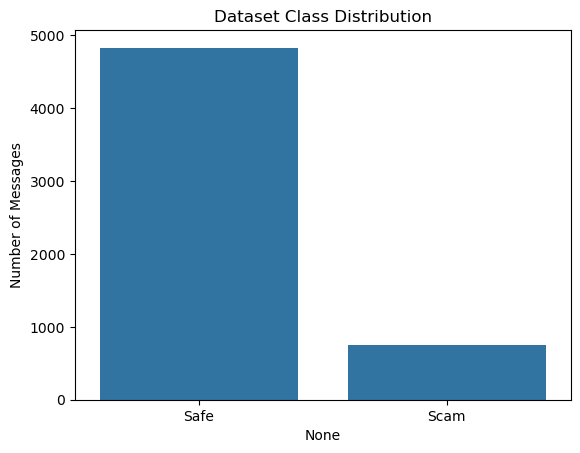

In [37]:
import seaborn as sns
import pandas as pd

labels_df = pd.Series(dataset['train']['label'])

sns.countplot(x=labels_df)
plt.xticks([0,1], ["Safe", "Scam"])
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Messages")
plt.show()

Epoch 1: Loss 0.018
Epoch 2: Loss 0.021
Epoch 3: Loss 0.017
Epoch 4: Loss 0.009
Epoch 5: Loss 0.012
Epoch 6: Loss 0.009
Epoch 7: Loss 0.015
Epoch 8: Loss 0.010
Epoch 9: Loss 0.009
Epoch 10: Loss 0.007


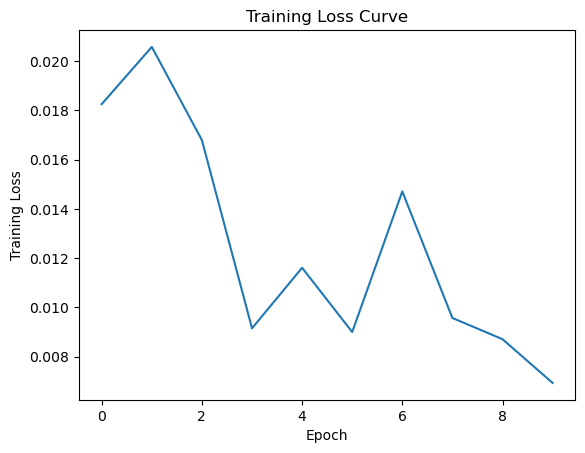

In [38]:
train_losses = []

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    train_losses.append(train_loss)

    print(f'Epoch {epoch+1}: Loss {train_loss:.3f}')

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

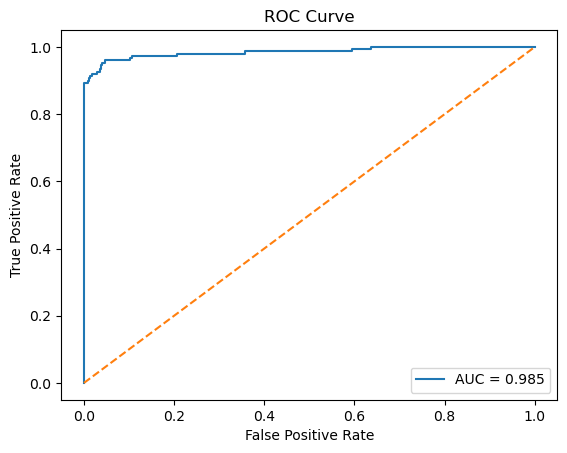

In [39]:
from sklearn.metrics import roc_curve, auc

all_probs = []

model.eval()

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        predictions = model(texts, lengths).squeeze(1)
        probs = torch.sigmoid(predictions)

        all_probs.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)

        alpha_t = torch.where(
            targets == 1,
            torch.full_like(targets, self.alpha),
            torch.full_like(targets, 1 - self.alpha)
        )

        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [48]:
model = ScamGuardLSTM(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    output_dim=1,
    n_layers=2,
    bidirectional=True,
    dropout=0.5
)
model.embedding.weight.data.copy_(embedding_matrix)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
#criterion = nn.BCEWithLogitsLoss() # Best for binary classification (Scam vs. Safe)
criterion = FocalLoss(alpha=0.75, gamma=2.0)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        
        # Calculate lengths: count how many non-zero tokens are in each row
        # (Assuming 0 is your <PAD> token index)
        lengths = (texts != 0).sum(dim=1).cpu() 
        
        optimizer.zero_grad()
        
        # Pass both arguments to the model
        predictions = model(texts, lengths).squeeze(1) 
        
        loss = criterion(predictions, labels.float())
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        preds = torch.round(torch.sigmoid(predictions))
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return epoch_loss / len(loader), correct / total

In [49]:
N_EPOCHS = 10
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    # valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    
    # Save the best model for the final report
    if train_loss < best_valid_loss:
        best_valid_loss = train_loss
        torch.save(model.state_dict(), 'scam-guard-lstm.pt')

Epoch: 01
	Train Loss: 0.024 | Train Acc: 91.52%
Epoch: 02
	Train Loss: 0.015 | Train Acc: 95.54%
Epoch: 03
	Train Loss: 0.011 | Train Acc: 96.48%
Epoch: 04
	Train Loss: 0.007 | Train Acc: 97.24%
Epoch: 05
	Train Loss: 0.007 | Train Acc: 97.78%
Epoch: 06
	Train Loss: 0.006 | Train Acc: 98.14%
Epoch: 07
	Train Loss: 0.004 | Train Acc: 98.86%
Epoch: 08
	Train Loss: 0.004 | Train Acc: 98.65%
Epoch: 09
	Train Loss: 0.003 | Train Acc: 98.81%
Epoch: 10
	Train Loss: 0.003 | Train Acc: 98.65%


In [50]:
valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train

In [51]:
print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc: {valid_acc*100:.2f}%')

	Valid Loss: 0.009 | Valid Acc: 97.67%


In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

def compute_metrics(model, loader, device):
    
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for texts, labels in loader:
            
            texts = texts.to(device)
            labels = labels.to(device)
            
            lengths = (texts != 0).sum(dim=1).cpu()
            
            logits = model(texts, lengths).squeeze(1)
            
            probs = torch.sigmoid(logits)
            preds = torch.round(probs)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    acc = accuracy_score(all_labels, all_preds)
    
    print("\nEvaluation Metrics")
    print("-------------------")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    print("\nClassification Report")
    print(classification_report(all_labels, all_preds))
    
    print("\nConfusion Matrix")
    print(confusion_matrix(all_labels, all_preds))
    
    return precision, recall, f1, acc

In [53]:
compute_metrics(model, test_loader, device)


Evaluation Metrics
-------------------
Accuracy  : 0.9767
Precision : 0.9020
Recall    : 0.9262
F1 Score  : 0.9139

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       966
           1       0.90      0.93      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix
[[951  15]
 [ 11 138]]


(0.9019607843137255,
 0.9261744966442953,
 0.9139072847682119,
 0.9766816143497757)

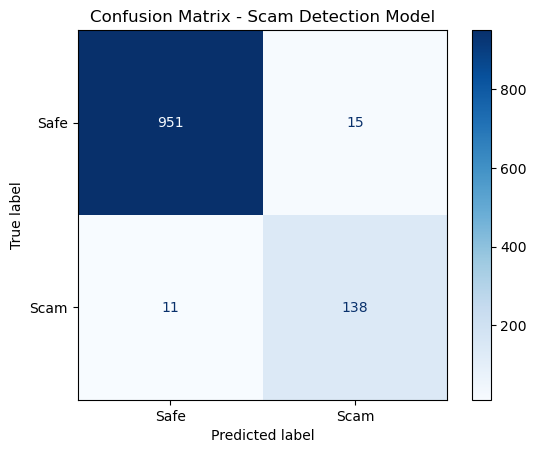

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        predictions = model(texts, lengths).squeeze(1)
        preds = torch.round(torch.sigmoid(predictions))

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Scam"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Scam Detection Model")
plt.show()